# **Coba + Analisis Disini**

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from imblearn.over_sampling import SMOTE

## **Input Data**

In [32]:
EXCEL_PATH = r'C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\dataset\hasil_ekstraksi_fitur.xlsx' 
df = pd.read_excel(EXCEL_PATH)
df = df.dropna(subset=['Anemia_Class', 'Hemoglobin', 'Age', 'Gender']) #hapus baris yang gada nilai

df['Gender'] = df['Gender'].map({'M': 1, 'F': 0})

print(df['Anemia_Class'].value_counts().sort_index())
df

Anemia_Class
0      3
1     50
2     37
3    121
Name: count, dtype: int64


,Country,Subject_ID,Age,Gender,mean_R,mean_G,mean_B,mean_L,mean_a,mean_b,mean_H,mean_S,mean_V,Hemoglobin,Anemia_Class
0,India,1,29,1,165.681334,82.346387,124.941774,118.559390,166.313710,124.941774,166.367962,130.298180,165.700354,12.2,2
1,India,2,36,0,159.608875,105.623553,119.549809,130.963319,154.832061,119.549809,160.096852,89.443007,160.550162,8.0,1
2,India,3,30,0,142.347389,81.613713,122.984434,108.931662,157.473051,122.984434,164.515150,112.148609,142.947018,10.7,1
3,India,4,39,0,172.217661,131.992063,115.307618,152.968773,149.983883,115.307618,150.293604,71.055925,178.894736,8.3,1
4,India,5,29,0,152.483330,82.745516,123.574996,113.115925,160.959679,123.574996,165.402269,118.849228,152.626490,7.8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206,Italy,119,41,1,182.296823,103.293776,127.557577,137.494227,163.514357,127.557577,165.420430,115.073579,182.645198,16.7,3
207,Italy,120,22,1,170.764561,81.862729,137.965371,118.729796,165.800599,137.965371,161.514427,134.032474,170.826102,15.4,3
208,Italy,121,40,0,169.481194,97.795846,130.600460,127.738470,159.342795,130.600460,171.723719,109.486959,169.556131,12.8,3
209,Italy,122,33,1,172.019362,97.620152,131.124113,129.280561,160.741626,131.124113,169.337852,113.329197,172.095139,15.7,3


## **MERGE**

In [33]:
df['Anemia_Class'] = df['Anemia_Class'].replace(0.0, 1.0) #-> Severe merge ke moderate
class_names = {3.0: 'Normal', 2.0: 'Mild', 1.0: 'Moderate/Severe'}

print("\n=== SETELAH MERGE Severe -> Moderate/Severe ===")
print(df['Anemia_Class'].map(class_names).value_counts())

df['Anemia_Class'] = df['Anemia_Class'].replace(1.0, 2.0) #-> Moderate/Severe + Mild -> Abnormal

df['Anemia_Class'] = df['Anemia_Class'].replace(2.0, 1.0) #-> Abnormal -> 1
df['Anemia_Class'] = df['Anemia_Class'].replace(3.0, 0.0) #-> Normal -> 0

class_names = {0.0: 'Normal (0)', 1.0: 'Abnormal (1)'}

print("\n=== SETELAH MERGE Moderate/Severe + Mild -> Abnormal ===")
print(df['Anemia_Class'].map(class_names).value_counts())

df


=== SETELAH MERGE Severe -> Moderate/Severe ===
Anemia_Class
Normal             121
Moderate/Severe     53
Mild                37
Name: count, dtype: int64

=== SETELAH MERGE Moderate/Severe + Mild -> Abnormal ===
Anemia_Class
Normal (0)      121
Abnormal (1)     90
Name: count, dtype: int64


,Country,Subject_ID,Age,Gender,mean_R,mean_G,mean_B,mean_L,mean_a,mean_b,mean_H,mean_S,mean_V,Hemoglobin,Anemia_Class
0,India,1,29,1,165.681334,82.346387,124.941774,118.559390,166.313710,124.941774,166.367962,130.298180,165.700354,12.2,1
1,India,2,36,0,159.608875,105.623553,119.549809,130.963319,154.832061,119.549809,160.096852,89.443007,160.550162,8.0,1
2,India,3,30,0,142.347389,81.613713,122.984434,108.931662,157.473051,122.984434,164.515150,112.148609,142.947018,10.7,1
3,India,4,39,0,172.217661,131.992063,115.307618,152.968773,149.983883,115.307618,150.293604,71.055925,178.894736,8.3,1
4,India,5,29,0,152.483330,82.745516,123.574996,113.115925,160.959679,123.574996,165.402269,118.849228,152.626490,7.8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206,Italy,119,41,1,182.296823,103.293776,127.557577,137.494227,163.514357,127.557577,165.420430,115.073579,182.645198,16.7,0
207,Italy,120,22,1,170.764561,81.862729,137.965371,118.729796,165.800599,137.965371,161.514427,134.032474,170.826102,15.4,0
208,Italy,121,40,0,169.481194,97.795846,130.600460,127.738470,159.342795,130.600460,171.723719,109.486959,169.556131,12.8,0
209,Italy,122,33,1,172.019362,97.620152,131.124113,129.280561,160.741626,131.124113,169.337852,113.329197,172.095139,15.7,0


## **Feature Selection + Splitting Data**

##### Splitting Data Declaration Code **kalo pake SMOTE**

In [35]:
#feature_columns = ['Age', 'Gender', 'mean_R', 'mean_G', 'mean_B', 'mean_L', 'mean_a', 'mean_b', 'mean_H', 'mean_S', 'mean_V'] #FFULL FEATURES
feature_columns = ['Gender', 'mean_a', 'mean_B', 'mean_b', 'mean_S', 'mean_R', 'mean_V']

X = df[feature_columns]
y_hb = df['Hemoglobin']
y_class = df['Anemia_Class']

# Splitting data (Gunakan stratify agar proporsi kelas di Train dan Test sama adilnya)
X_train, X_test, y_hb_train, y_hb_test, y_class_train, y_class_test = train_test_split(
    X, y_hb, y_class, test_size=0.2, random_state=42, stratify=y_class
)

##### Splitting Data Declaration Code **kalo gapake SMOTE**

In [ ]:
feature_columns = ['Age', 'Gender', 'mean_R', 'mean_G', 'mean_B', 'mean_L', 'mean_a', 'mean_b', 'mean_H', 'mean_S', 'mean_V']

X = df[feature_columns]
y = df['Hemoglobin']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

## **FEATURE SELECTION**

### **PEARSON CORRELATION COEFFICIENT (PCC)**

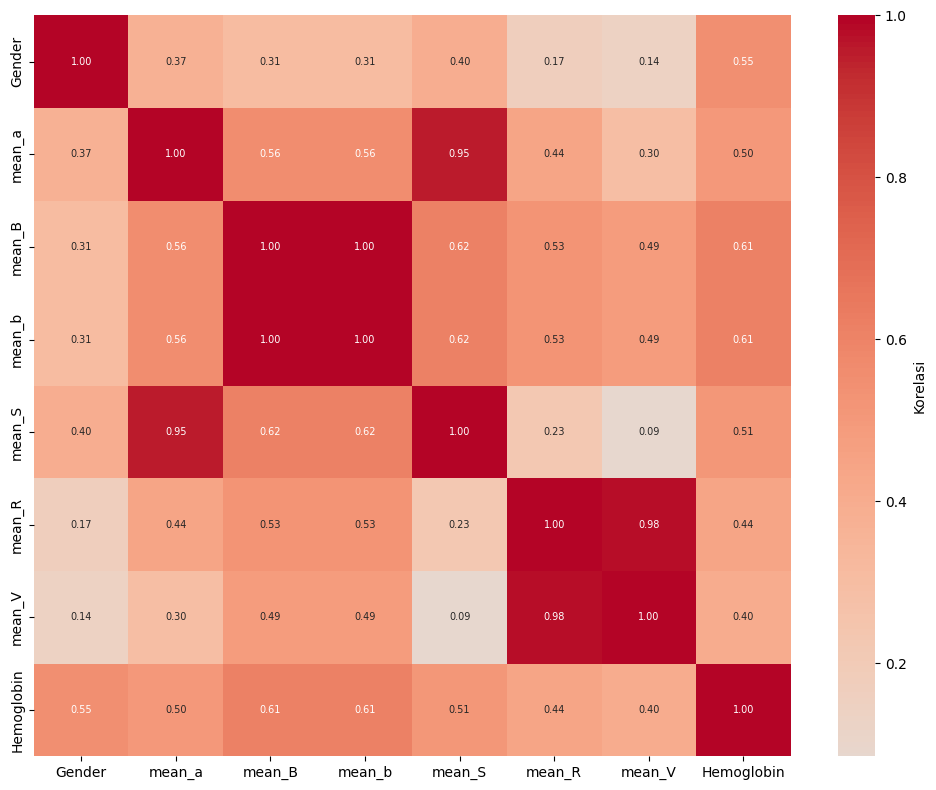

In [43]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

#Pearson Correlation Coefficient (PCC)
plt.figure(figsize=(10, 8))
#correlation_matrix = df[feature_columns + ['Hemoglobin']].corr(method='pearson')

correlation_matrix = df[feature_columns + ['Hemoglobin']].corr(method='pearson')
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, cbar_kws={'label': 'Korelasi'}, annot_kws={'fontsize': 7})

plt.tight_layout()
plt.show()

## **SMOTE Declaration Code**

In [37]:
print("Jumlah data TRAIN sebelum SMOTE:")
print(y_class_train.value_counts())

# Trik SMOTE untuk Regresi: Gabungkan fitur (X) dan target (Hemoglobin) sementara
train_data_combined = pd.concat([X_train, y_hb_train], axis=1)

# Lakukan SMOTE berdasarkan label Anemia_Class
smote = SMOTE(random_state=42)
train_data_resampled, y_class_resampled = smote.fit_resample(train_data_combined, y_class_train)

# Pisahkan kembali fitur (X) dan Hemoglobin (y) setelah diperbanyak
X_train_balanced = train_data_resampled[feature_columns].copy()
y_hb_train_balanced = train_data_resampled['Hemoglobin']

# PERBAIKAN PENTING: SMOTE kadang menghasilkan nilai desimal (misal Gender 0.6).
# Kita harus membulatkan nilai Gender kembali ke 0 atau 1.
X_train_balanced['Gender'] = X_train_balanced['Gender'].round().astype(int)

print("\nJumlah data TRAIN setelah SMOTE:")
print(y_class_resampled.value_counts())

display(X_train_balanced.head())

Jumlah data TRAIN sebelum SMOTE:
Anemia_Class
0    96
1    72
Name: count, dtype: int64

Jumlah data TRAIN setelah SMOTE:
Anemia_Class
1    96
0    96
Name: count, dtype: int64


,Gender,mean_a,mean_B,mean_b,mean_S,mean_R,mean_V
0,0,142.398763,117.582023,117.582023,64.551646,148.128963,160.822580
1,1,142.657975,119.528590,119.528590,57.289869,159.022448,167.217739
2,1,144.177308,121.954538,121.954538,74.732236,146.968080,154.792301
3,0,157.063836,129.219450,129.219450,95.324671,181.755278,181.755278
4,0,153.664458,116.652510,116.652510,78.371821,172.507216,174.406413


##### **VISUALIZATION**

,Gender,mean_a,mean_B,mean_b,mean_S,mean_R,mean_V,Hemoglobin
0,0,142.398763,117.582023,117.582023,64.551646,148.128963,160.822580,10.93
1,1,142.657975,119.528590,119.528590,57.289869,159.022448,167.217739,9.20
2,1,144.177308,121.954538,121.954538,74.732236,146.968080,154.792301,15.45
3,0,157.063836,129.219450,129.219450,95.324671,181.755278,181.755278,7.00
4,0,153.664458,116.652510,116.652510,78.371821,172.507216,174.406413,8.90


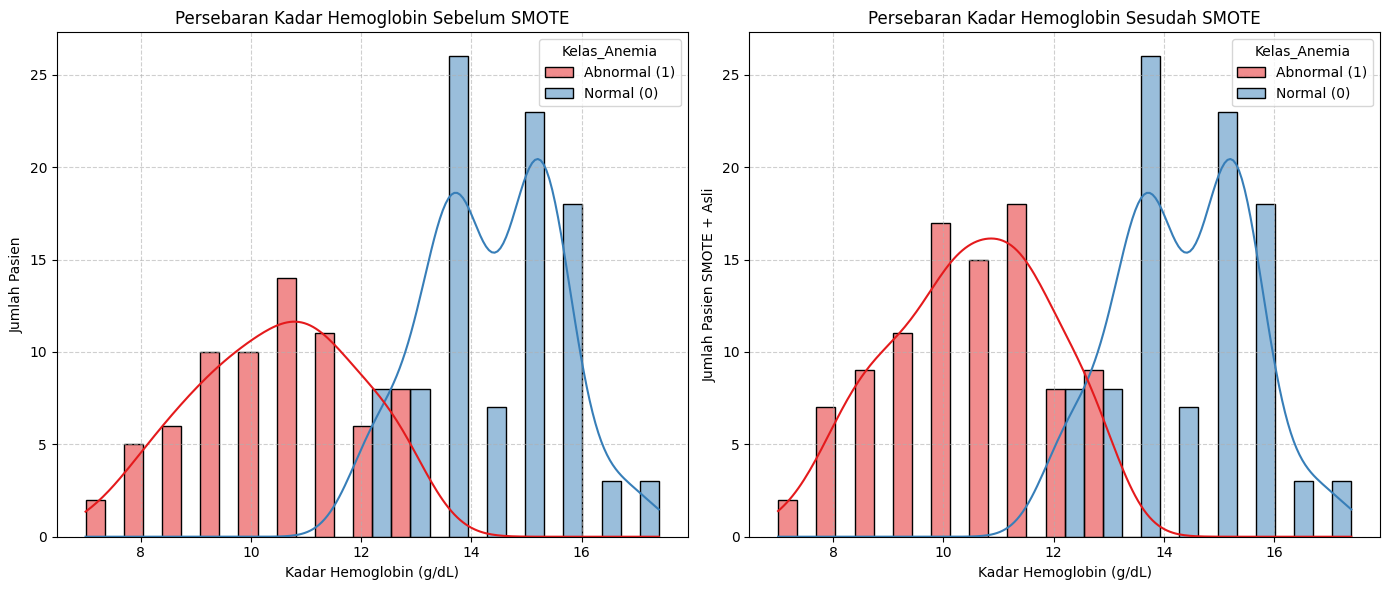

In [38]:
train_data_resampled['Gender'] = train_data_resampled['Gender'].round().astype(int)
from IPython.display import display
display(train_data_resampled.head())

# 2. Visualisasi Persebaran Angka Hemoglobin (Histogram/KDE)
train_data_combined['Kelas_Anemia'] = y_class_train.map(class_names)
train_data_resampled['Kelas_Anemia'] = y_class_resampled.map(class_names)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Grafik Kiri: Sebelum SMOTE
sns.histplot(ax=axes[0], data=train_data_combined, x='Hemoglobin', hue='Kelas_Anemia', 
             palette='Set1', bins=15, kde=True, multiple="dodge", edgecolor='k')
axes[0].set_title('Persebaran Kadar Hemoglobin Sebelum SMOTE')
axes[0].set_xlabel('Kadar Hemoglobin (g/dL)')
axes[0].set_ylabel('Jumlah Pasien')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Grafik Kanan: Sesudah SMOTE
sns.histplot(ax=axes[1], data=train_data_resampled, x='Hemoglobin', hue='Kelas_Anemia', 
             palette='Set1', bins=15, kde=True, multiple="dodge", edgecolor='k')
axes[1].set_title('Persebaran Kadar Hemoglobin Sesudah SMOTE')
axes[1].set_xlabel('Kadar Hemoglobin (g/dL)')
axes[1].set_ylabel('Jumlah Pasien SMOTE + Asli')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Menghapus kolom sementara agar aman untuk proses training selanjutnya
train_data_combined.drop(columns=['Kelas_Anemia'], inplace=True)
train_data_resampled.drop(columns=['Kelas_Anemia'], inplace=True)

## **MODEL DECLARATION**

In [39]:
model_params = {
    'MLR': {}, 
    'SVR': {'kernel': 'rbf', 'C': 1.0, 'gamma': 'scale'},
    'Random Forest': {'max_depth': 4, 'n_estimators': 20, 'random_state': 42},
    'Gradient Boosting': {'max_depth': 4, 'learning_rate': 0.1, 'n_estimators': 20, 'random_state': 42}
}

models = {
    'MLR': make_pipeline(StandardScaler(), LinearRegression(**model_params['MLR'])),
    'SVR': make_pipeline(StandardScaler(), SVR(**model_params['SVR'])),
    'Random Forest': make_pipeline(StandardScaler(), RandomForestRegressor(**model_params['Random Forest'])),
    'Gradient Boosting': make_pipeline(StandardScaler(), GradientBoostingRegressor(**model_params['Gradient Boosting']))
}

## **TRAINING RESULT**

##### **BALANCED DATA**

In [40]:
results = {}
predictions_dict = {}

for name, model in models.items():
    model.fit(X_train_balanced, y_hb_train_balanced)
    
    y_pred = model.predict(X_test)
    predictions_dict[name] = y_pred
    
    mse = mean_squared_error(y_hb_test, y_pred)
    mae = mean_absolute_error(y_hb_test, y_pred)
    r2 = r2_score(y_hb_test, y_pred)
    
    results[name] = {'MSE': mse, 'MAE (Error g/dL)': mae, 'R2 Score': r2}

results_df = pd.DataFrame(results).T
from IPython.display import display
print("\n=== HASIL EVALUASI MODEL ===")
display(results_df.sort_values(by='MAE (Error g/dL)'))


=== HASIL EVALUASI MODEL ===


,MSE,MAE (Error g/dL),R2 Score
Random Forest,2.205345,1.149228,0.600026
SVR,2.161681,1.182778,0.607945
Gradient Boosting,2.328148,1.184430,0.577753
MLR,2.747089,1.385305,0.501772


##### **UNBALANCED DATA**

In [ ]:
results = {}
predictions_dict = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    
    # predict
    y_pred = model.predict(X_test)
    predictions_dict[name] = y_pred 
    
    #mse
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {'MSE': mse, 'MAE (Error g/dL)': mae, 'R2 Score': r2}

results_df = pd.DataFrame(results).T
print("\n=== HASIL EVALUASI MODEL ===")
display(results_df.sort_values(by='MAE (Error g/dL)'))

#### **VISUALIZATION**

##### BALANCED DATA

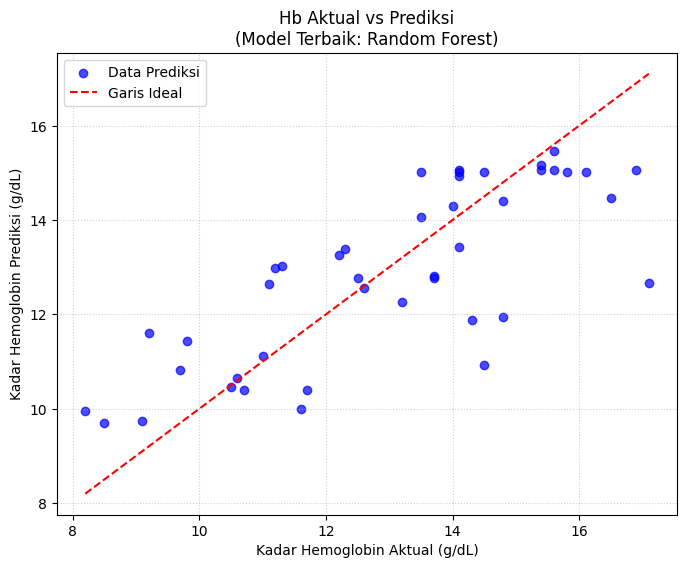

In [41]:
best_model_name = results_df['MAE (Error g/dL)'].idxmin()
best_y_pred = predictions_dict[best_model_name]

plt.figure(figsize=(8, 6))
plt.scatter(y_hb_test, best_y_pred, alpha=0.7, color='blue', label='Data Prediksi')

min_val = min(min(y_hb_test), min(best_y_pred))
max_val = max(max(y_hb_test), max(best_y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Garis Ideal')

plt.title(f'Hb Aktual vs Prediksi\n(Model Terbaik: {best_model_name})')
plt.xlabel('Kadar Hemoglobin Aktual (g/dL)')
plt.ylabel('Kadar Hemoglobin Prediksi (g/dL)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

##### UNBALANCED DATA

In [ ]:
best_model_name = results_df['MAE (Error g/dL)'].idxmin()
best_y_pred = predictions_dict[best_model_name]

plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_y_pred, alpha=0.7, color='blue', label='Data Prediksi')

min_val = min(min(y_test), min(best_y_pred))
max_val = max(max(y_test), max(best_y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Garis Ideal')

plt.title(f'Hb Aktual vs Prediksi\n(Model Terbaik: {best_model_name})')
plt.xlabel('Kadar Hemoglobin Aktual (g/dL)')
plt.ylabel('Kadar Hemoglobin Prediksi (g/dL)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()